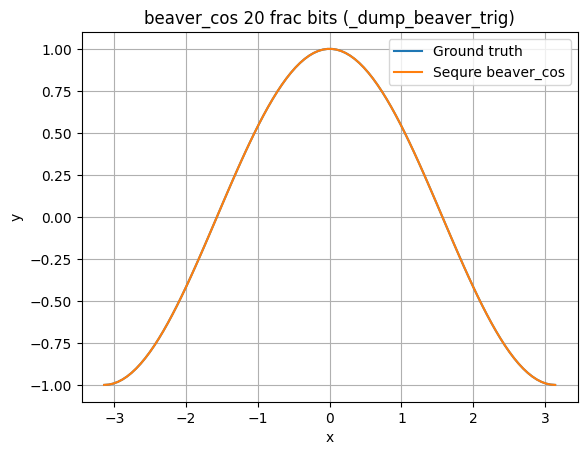

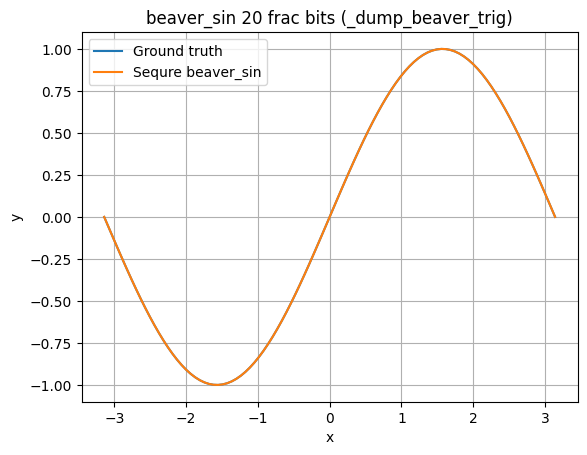

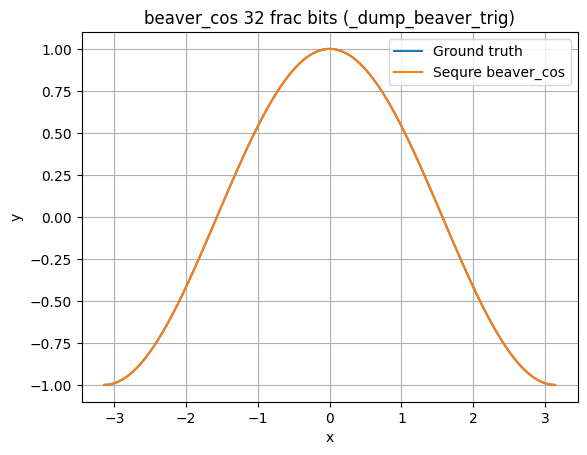

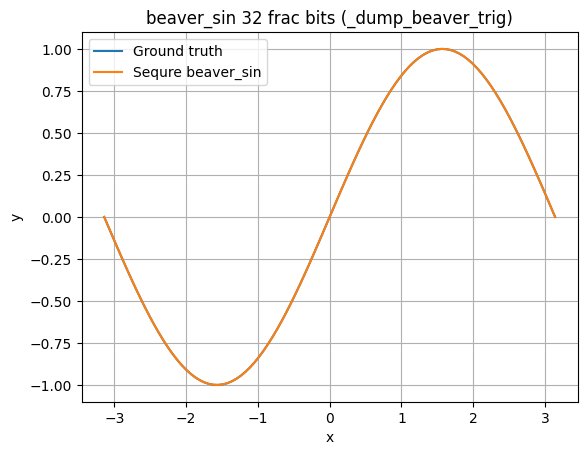

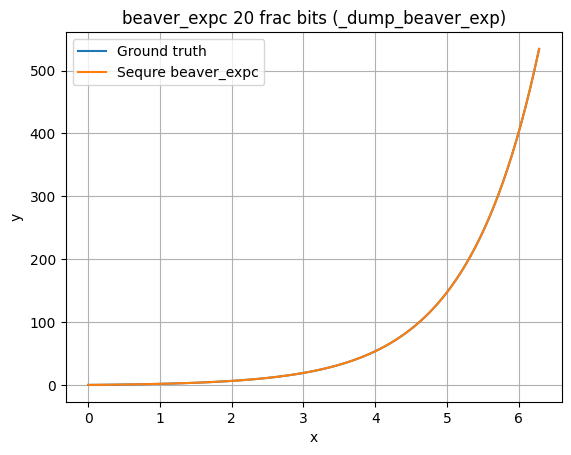

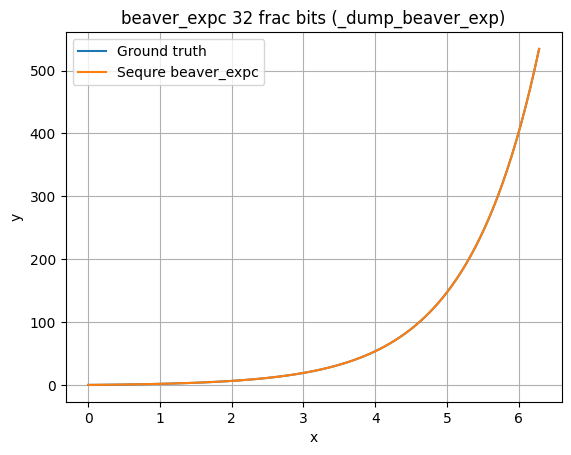

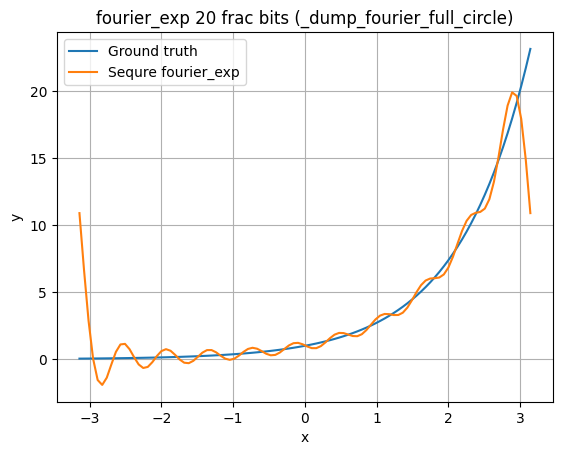

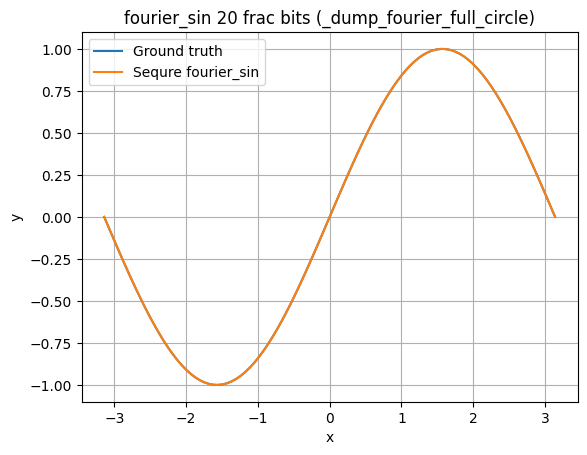

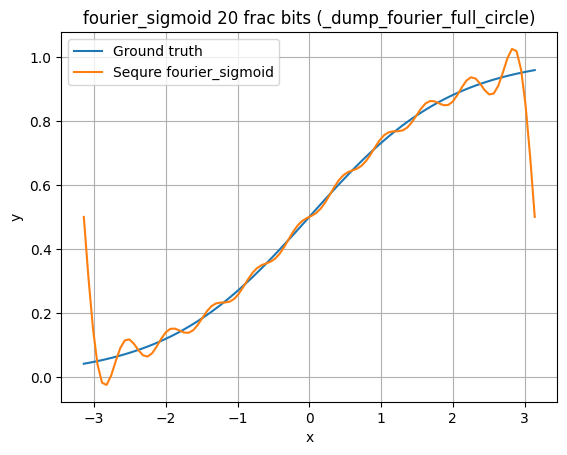

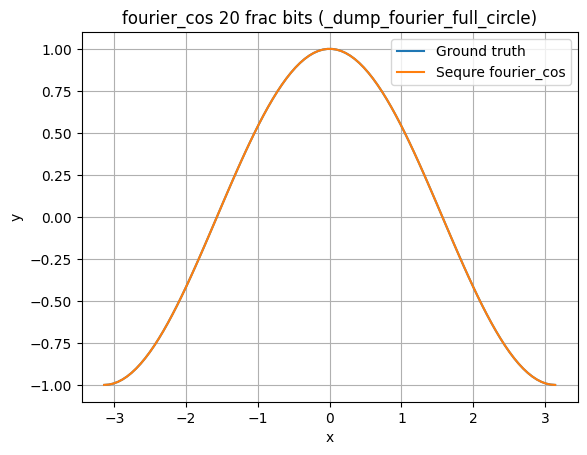

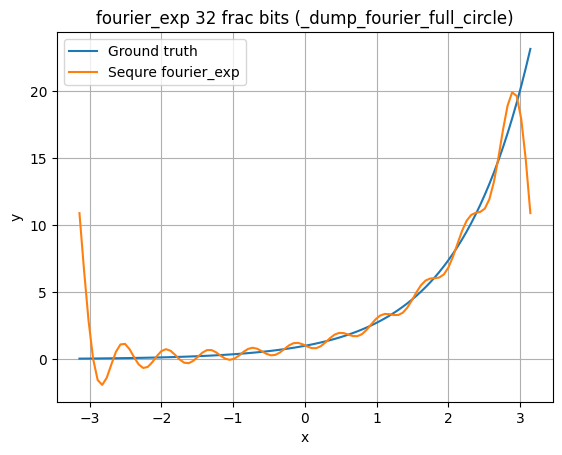

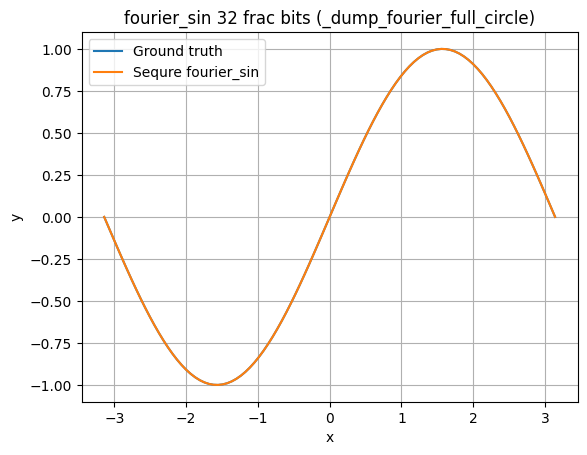

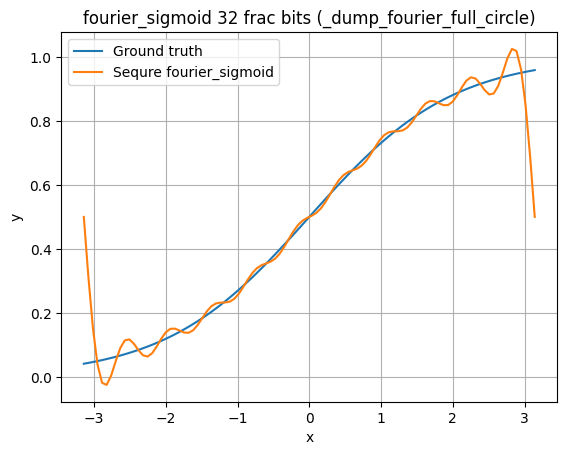

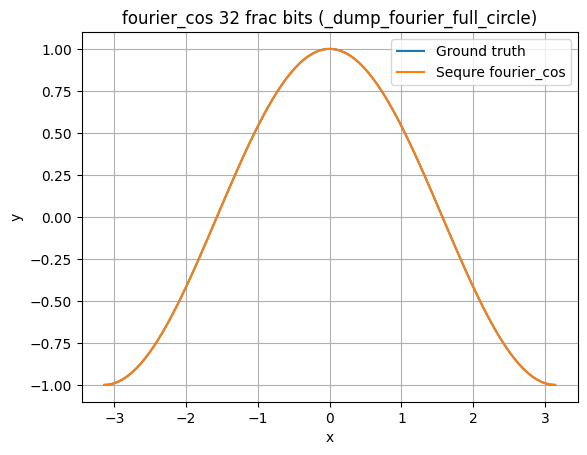

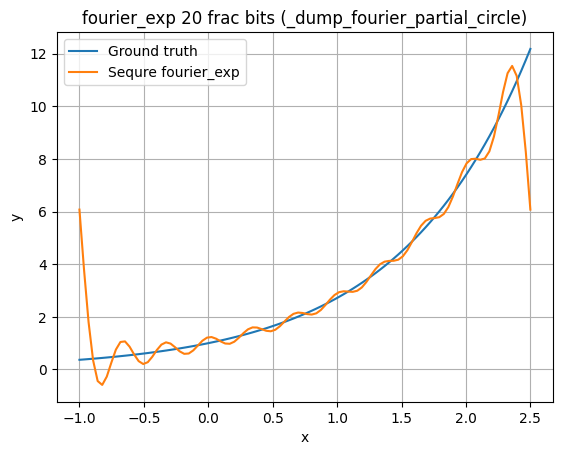

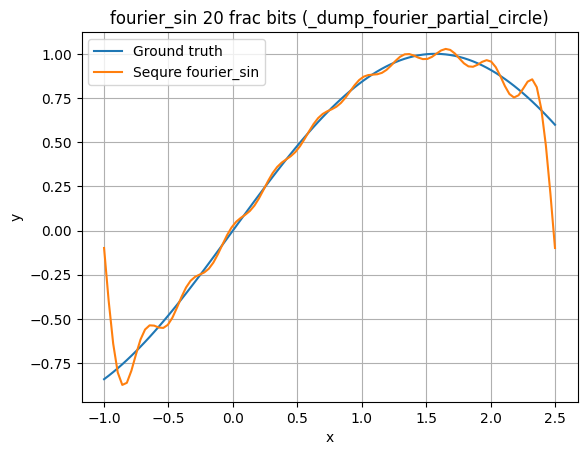

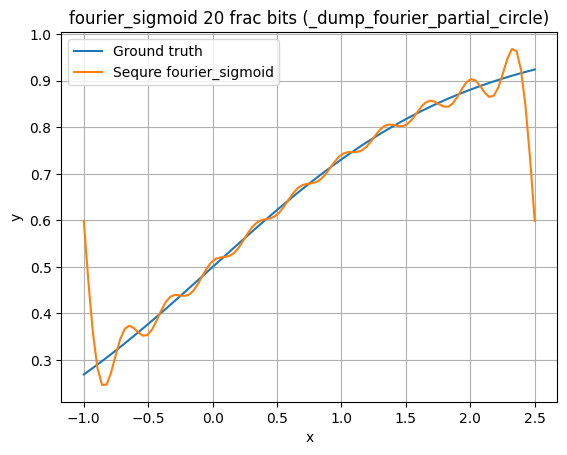

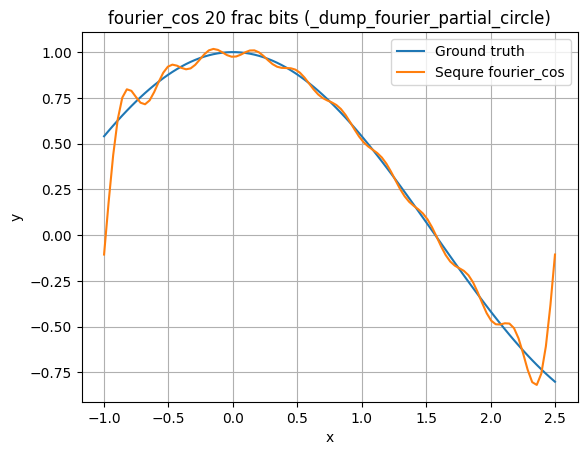

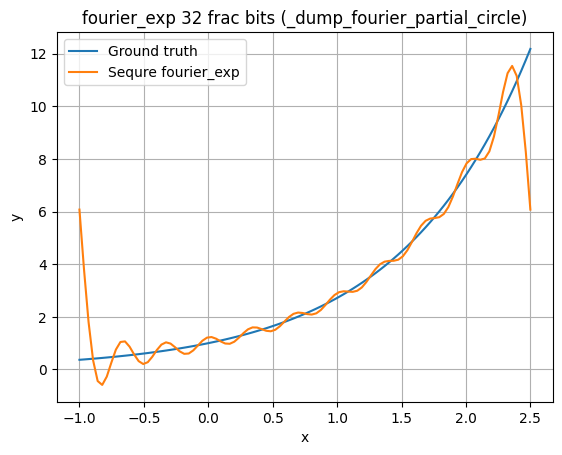

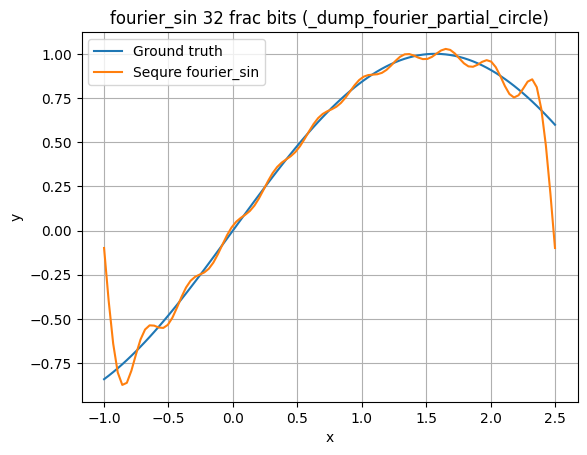

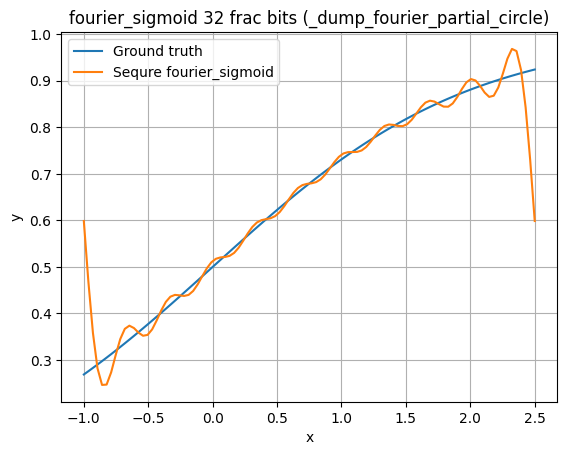

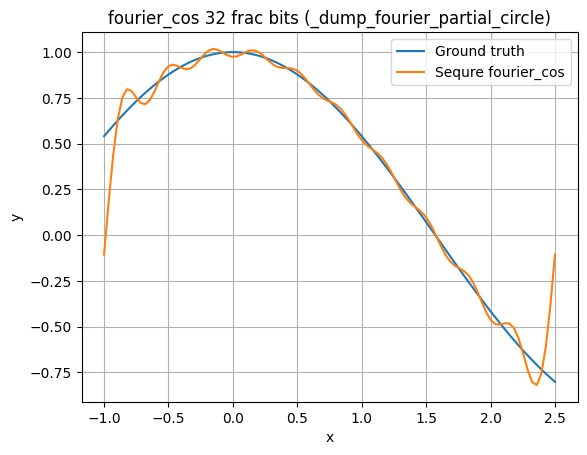

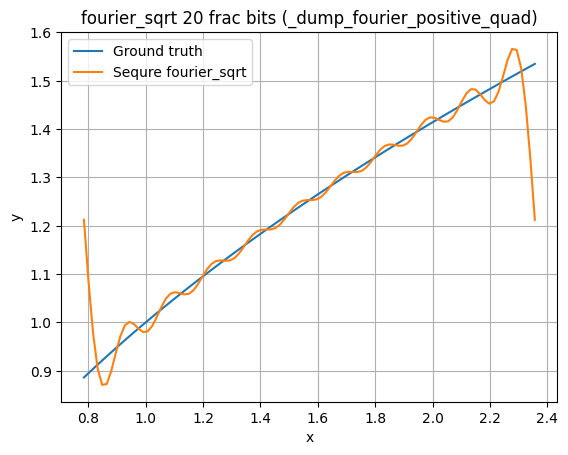

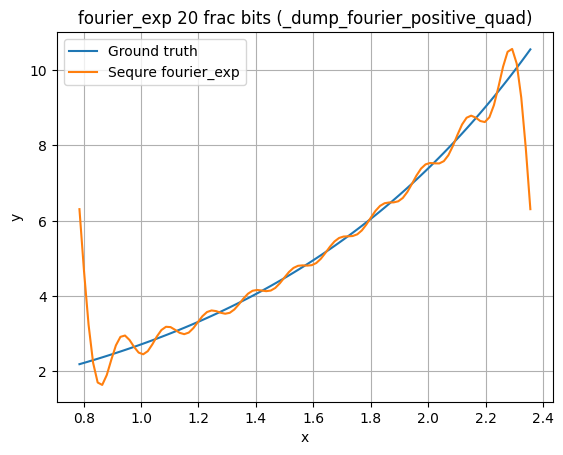

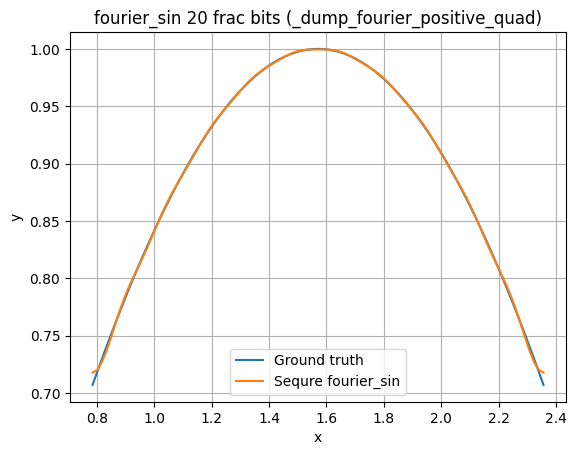

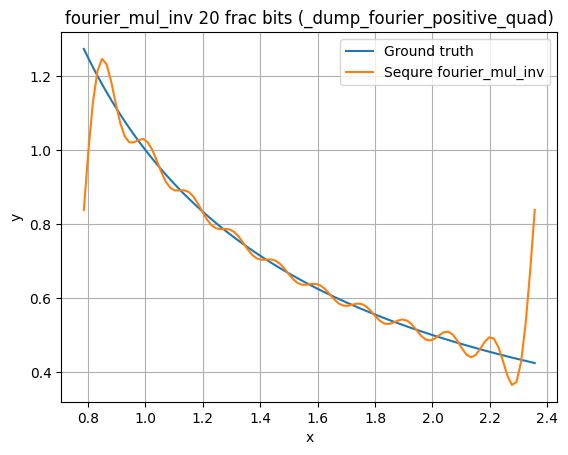

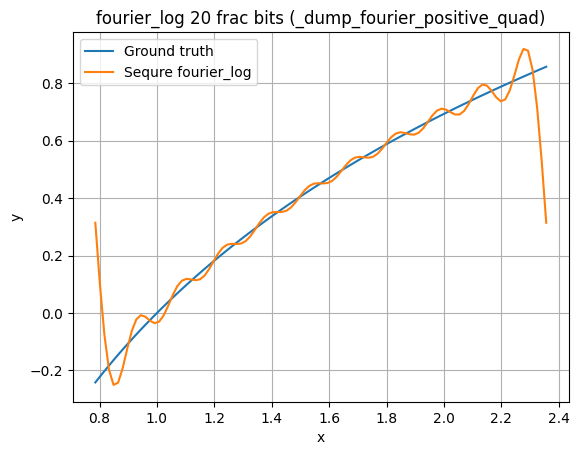

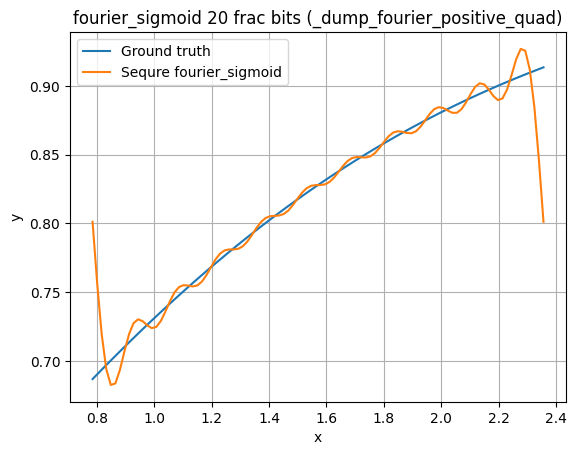

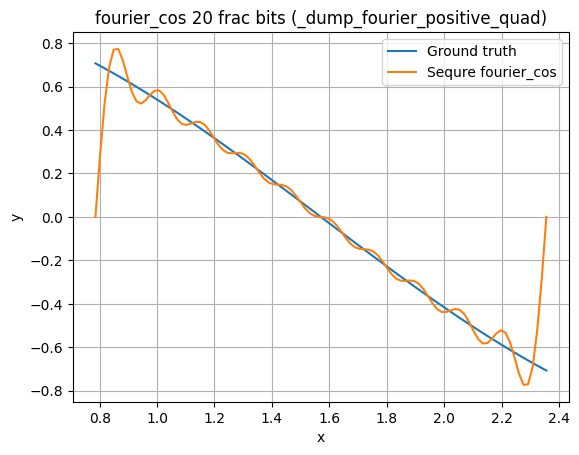

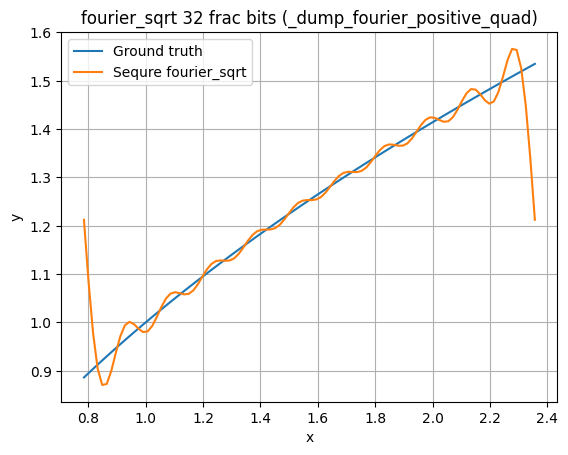

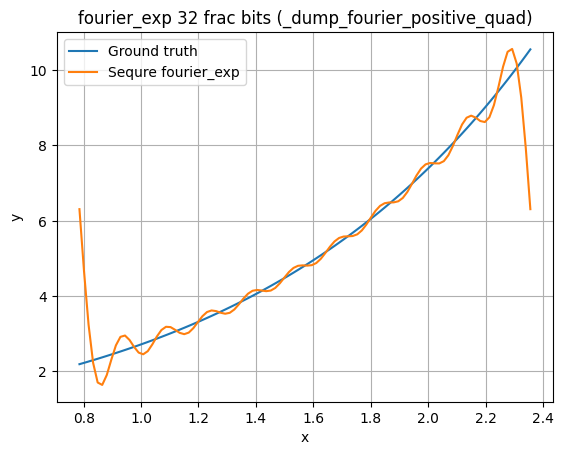

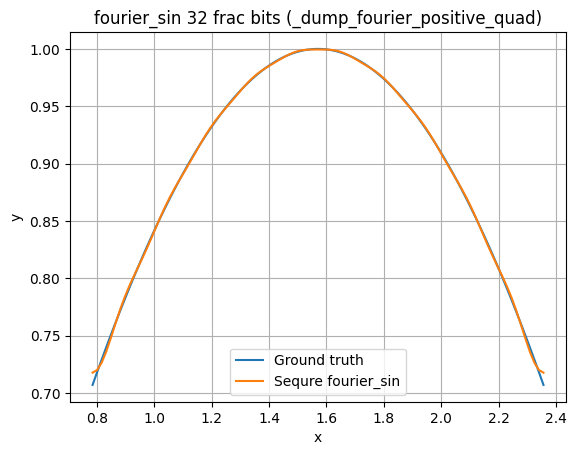

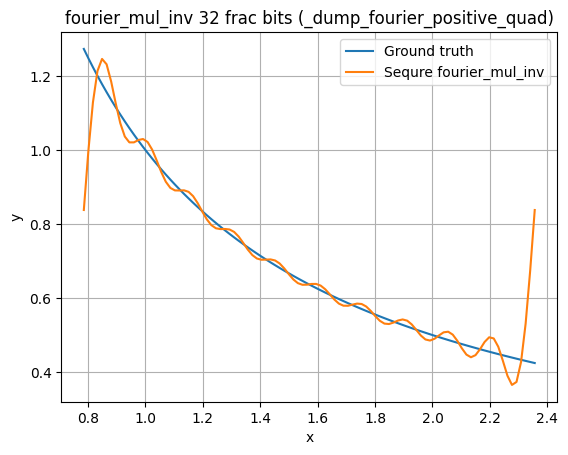

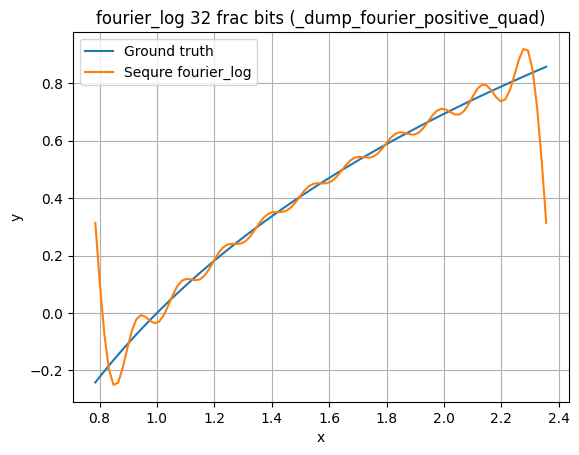

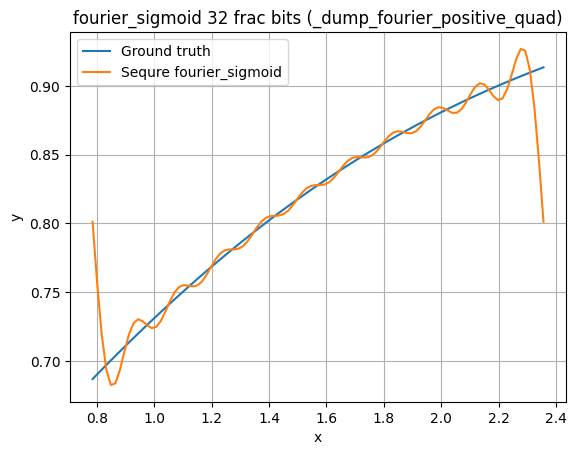

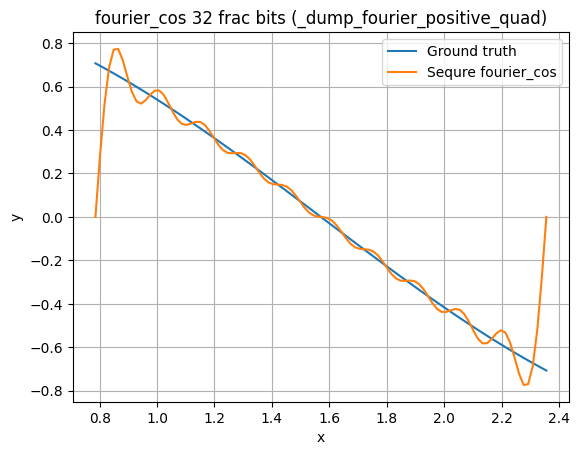

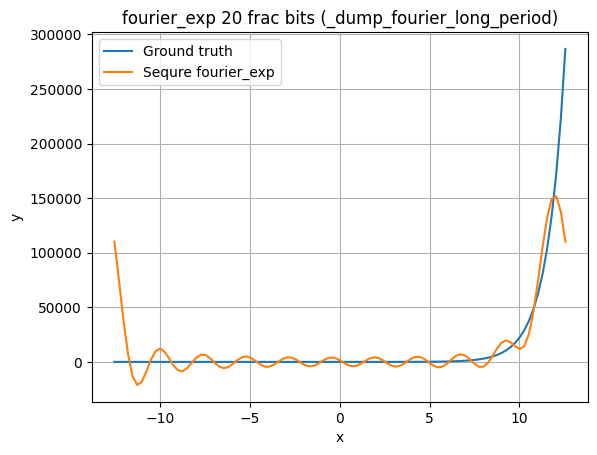

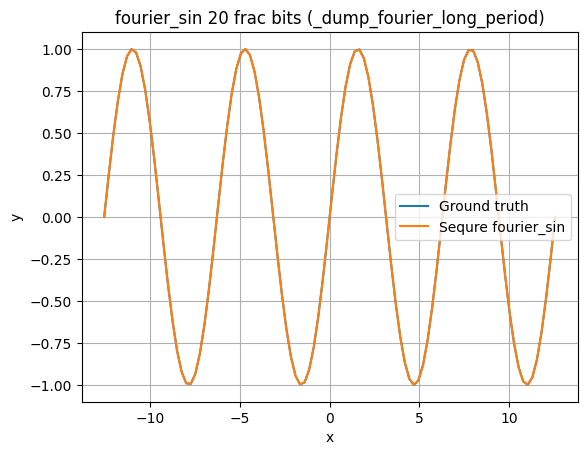

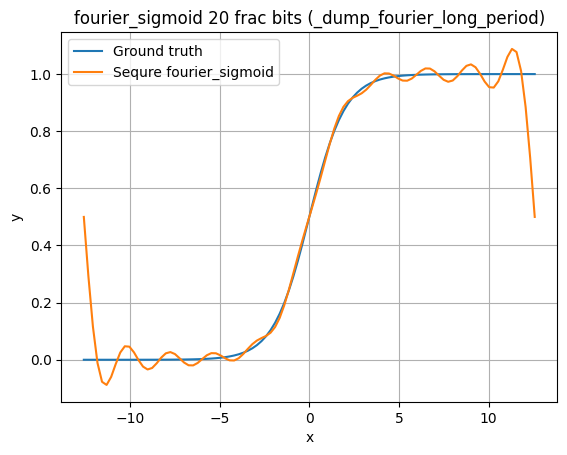

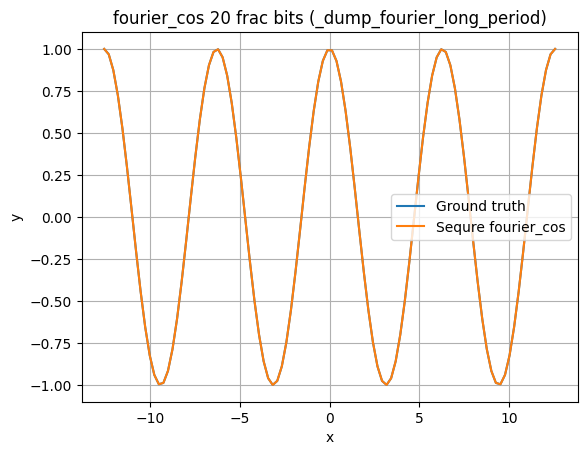

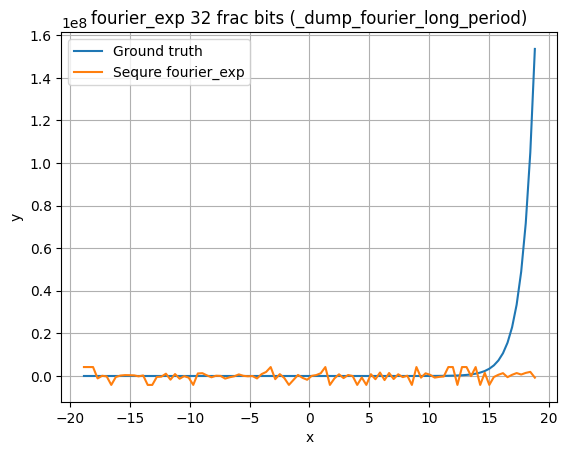

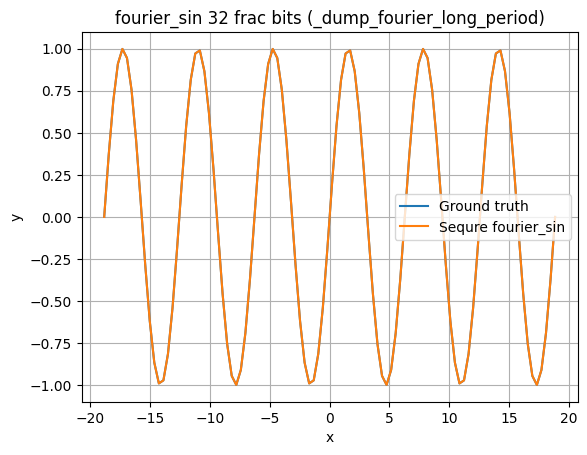

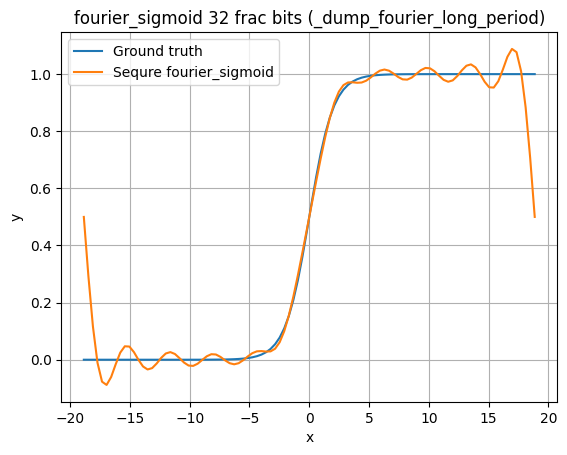

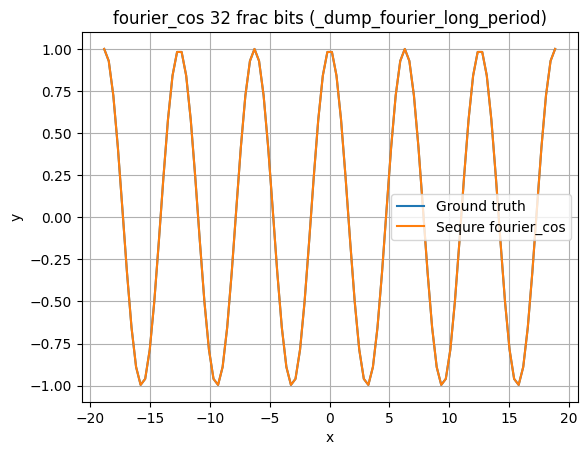

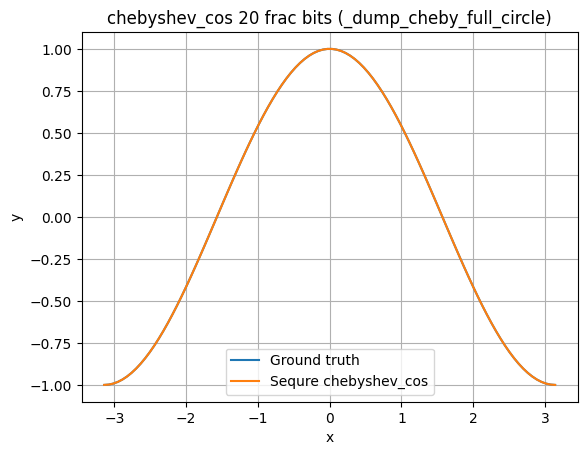

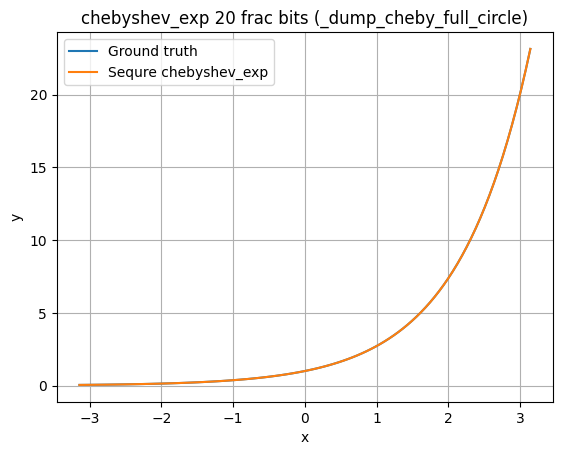

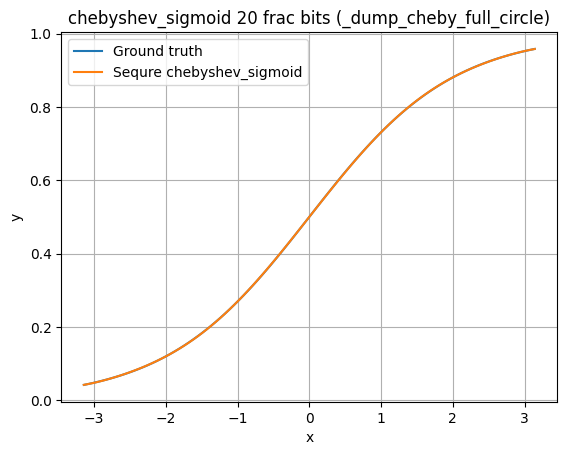

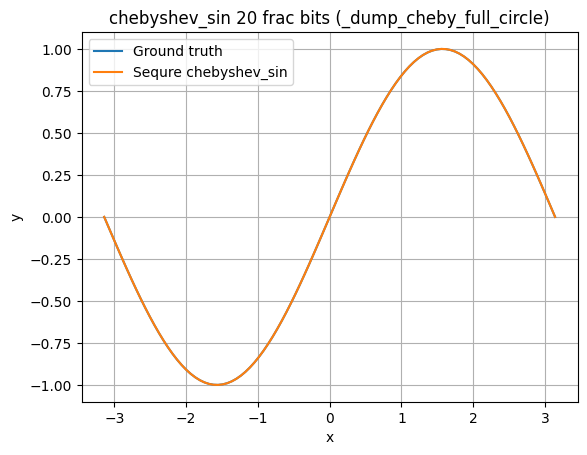

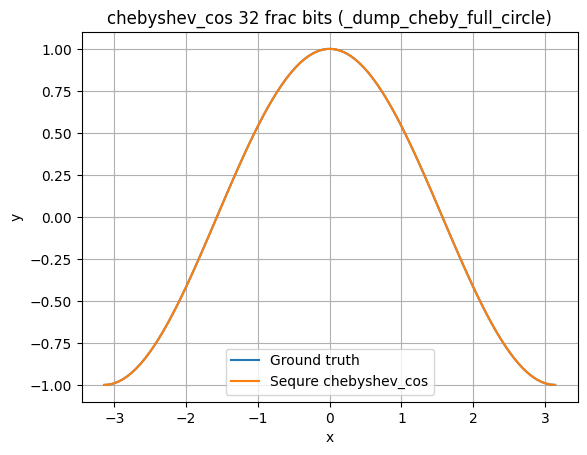

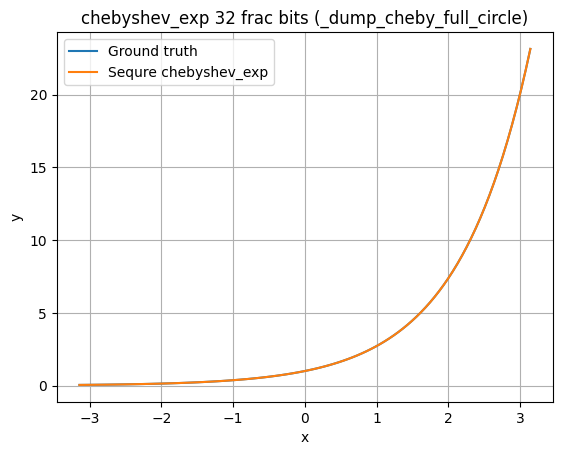

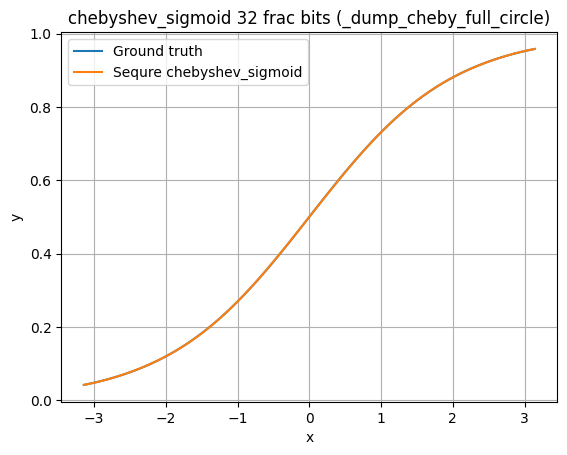

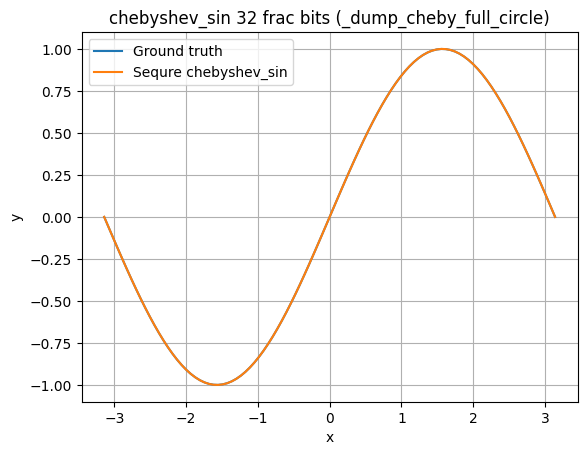

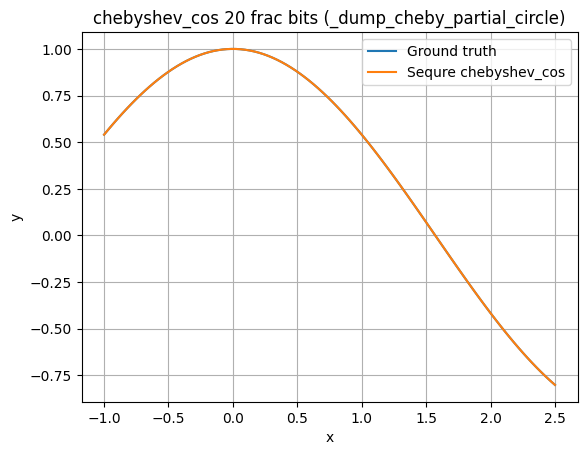

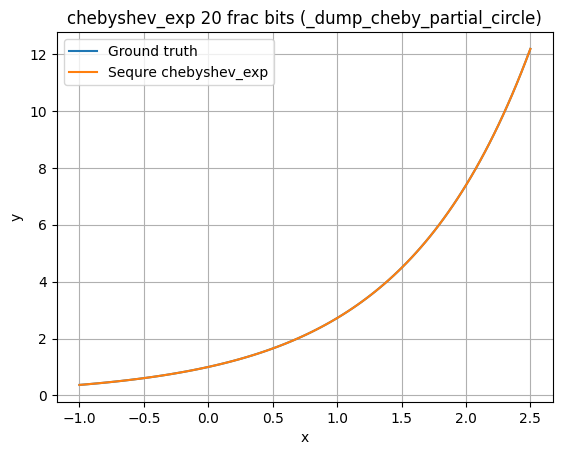

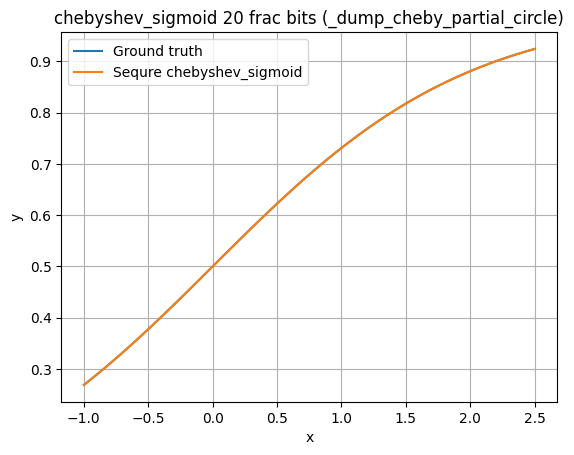

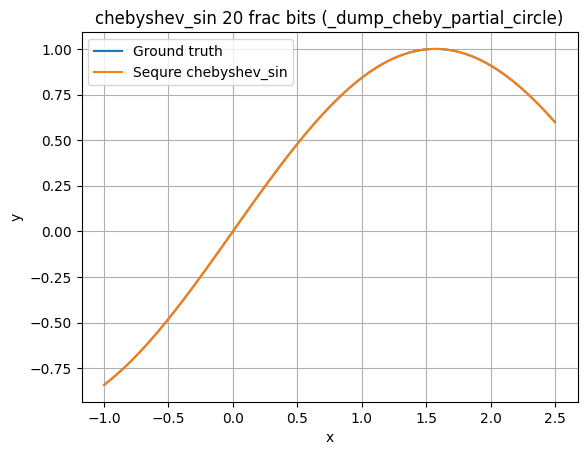

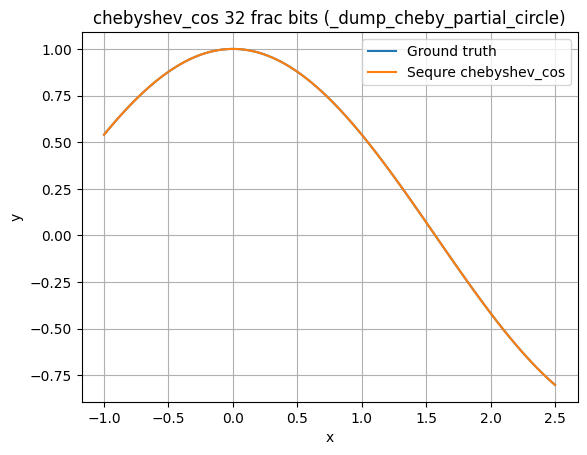

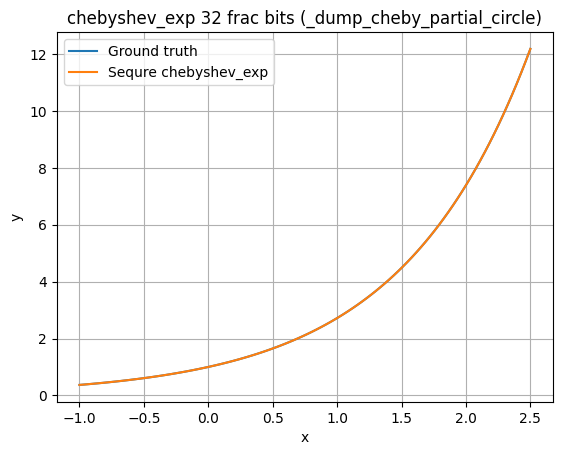

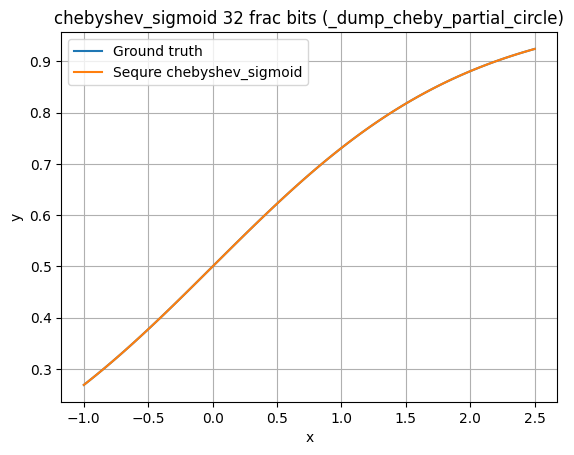

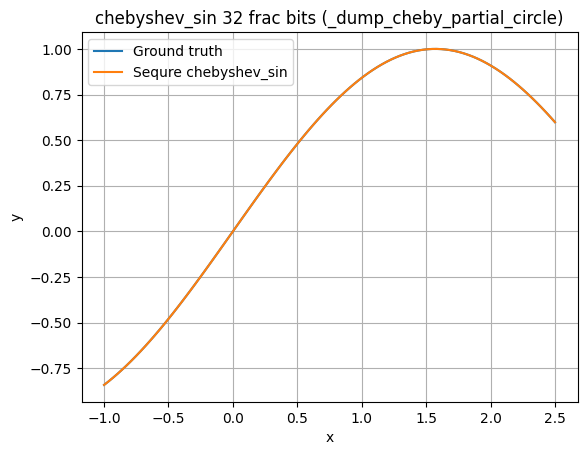

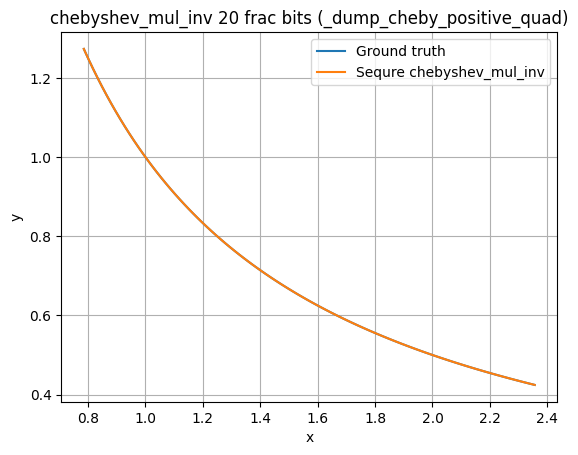

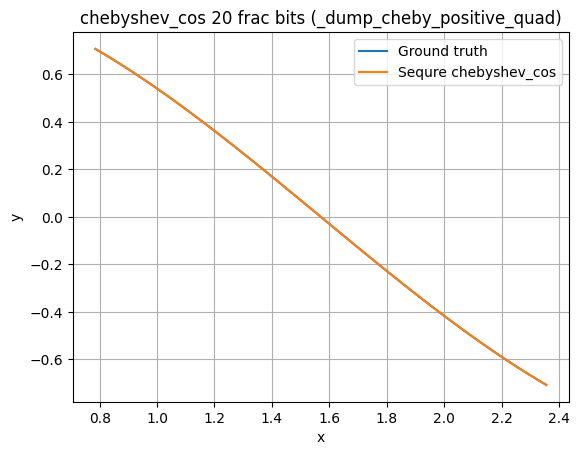

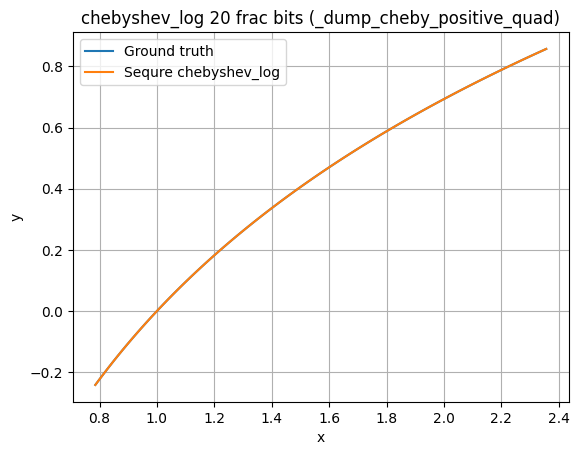

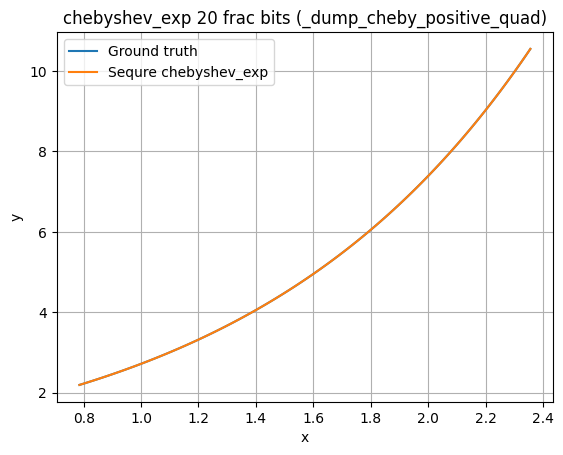

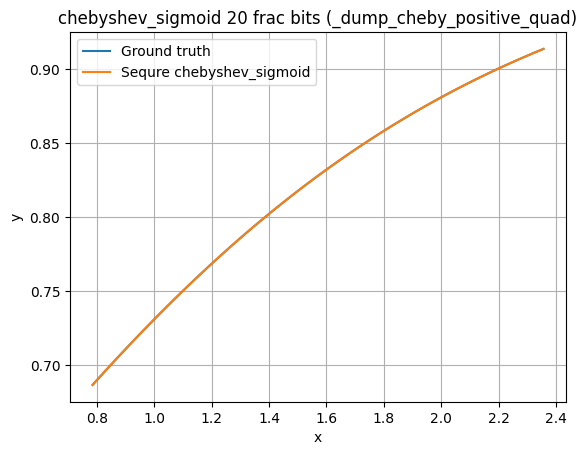

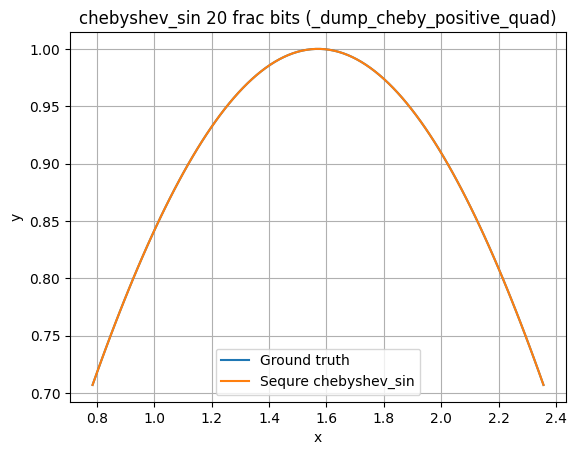

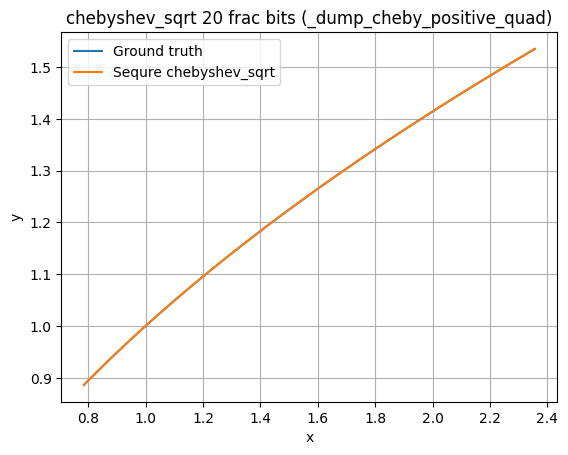

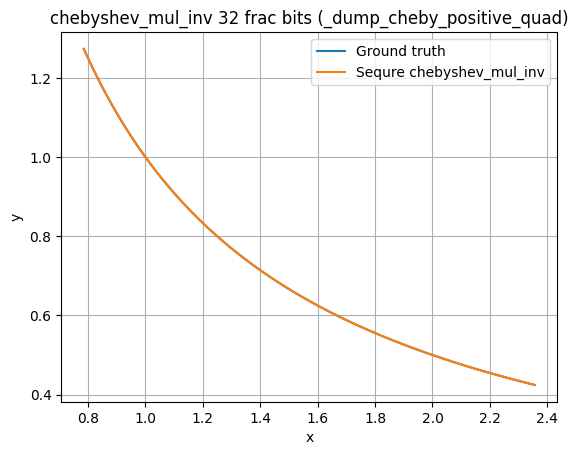

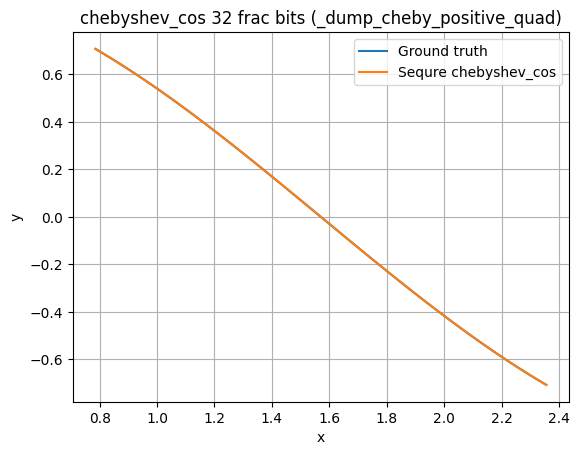

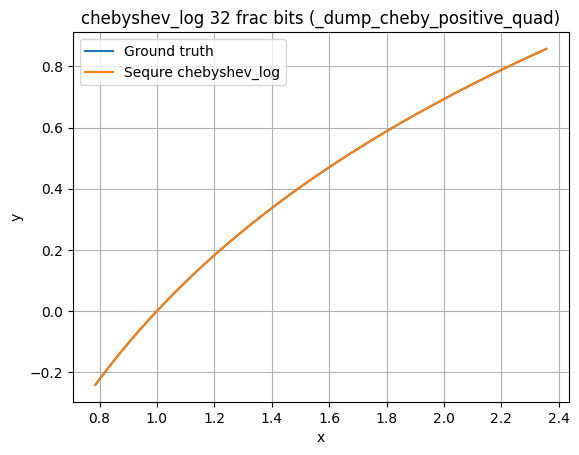

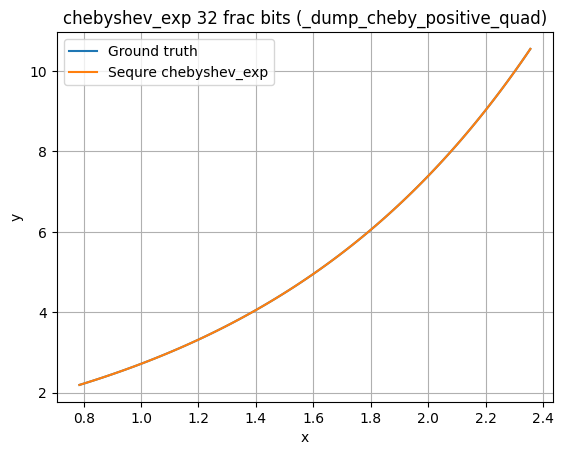

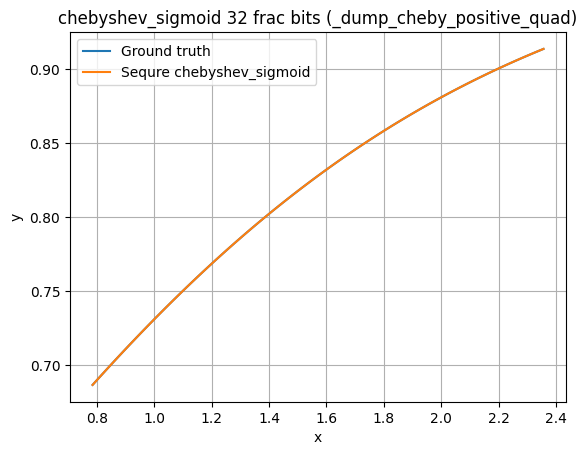

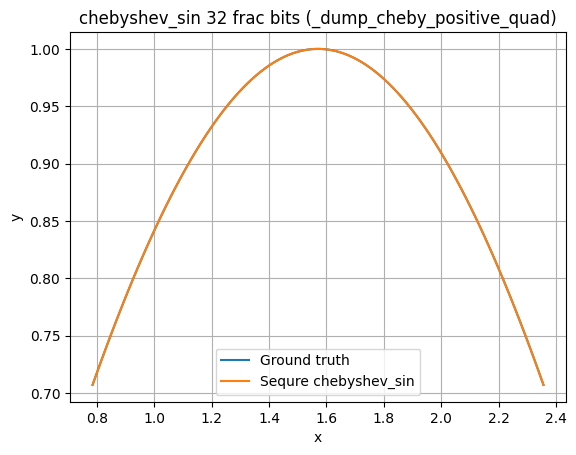

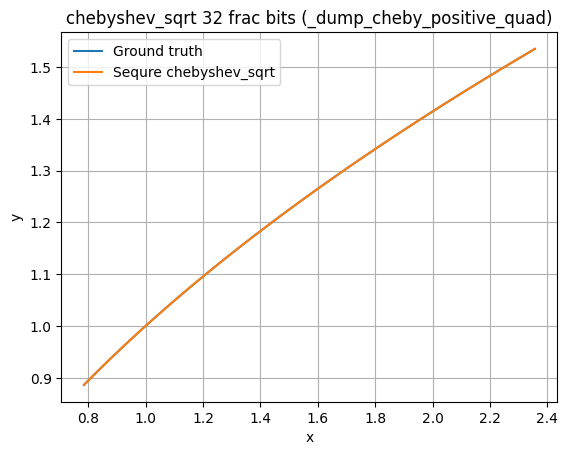

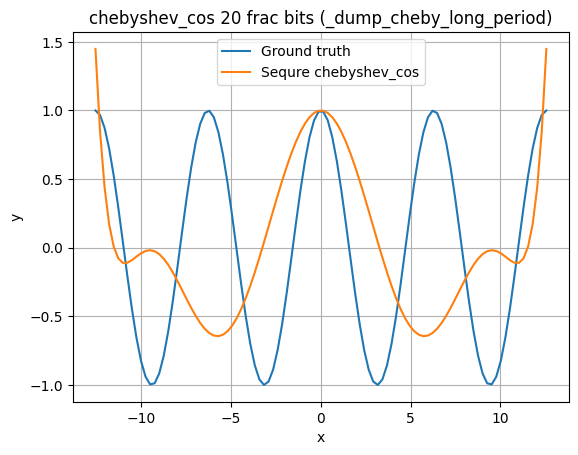

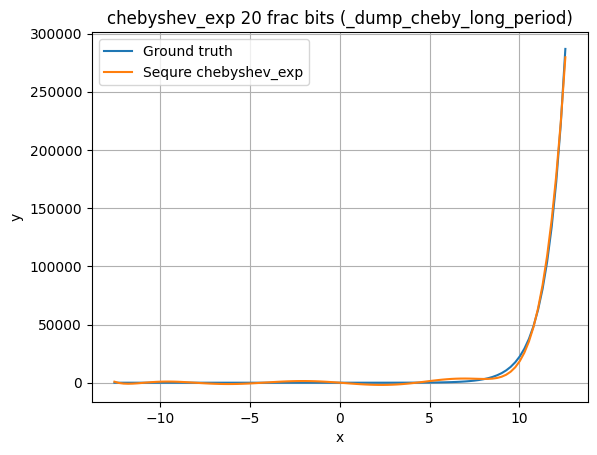

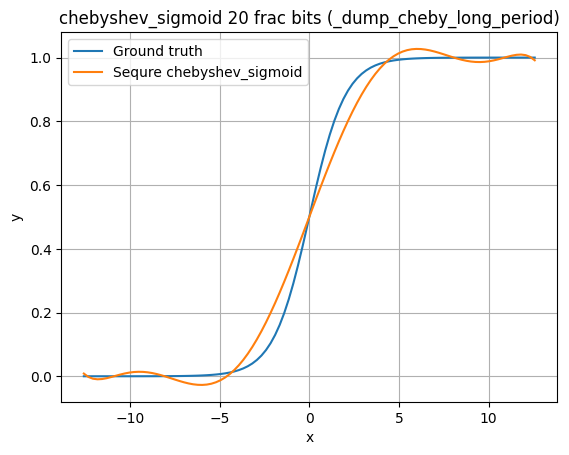

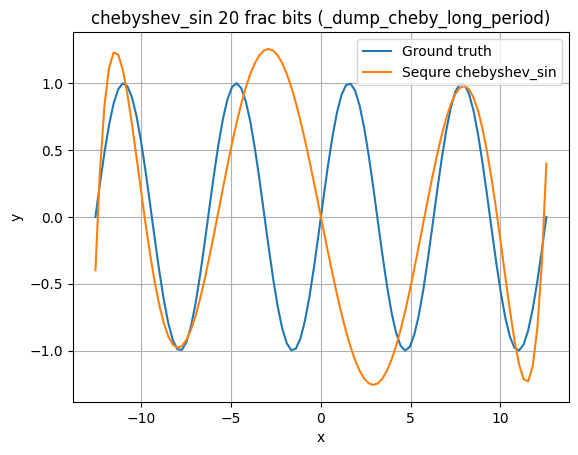

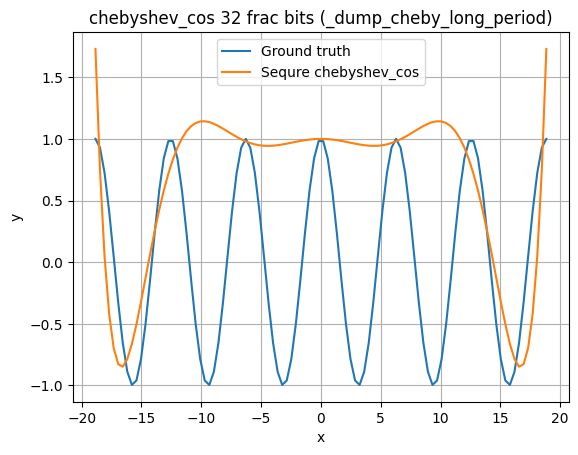

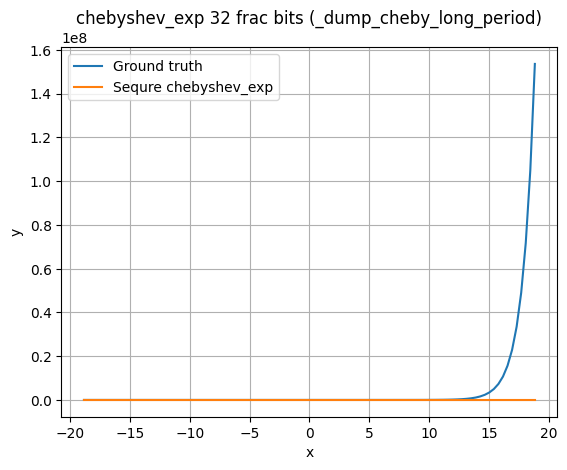

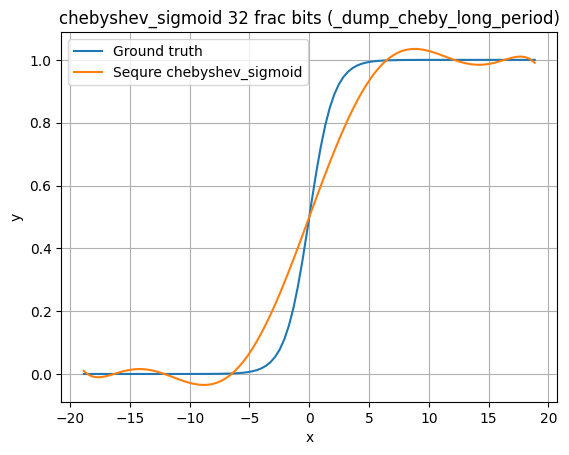

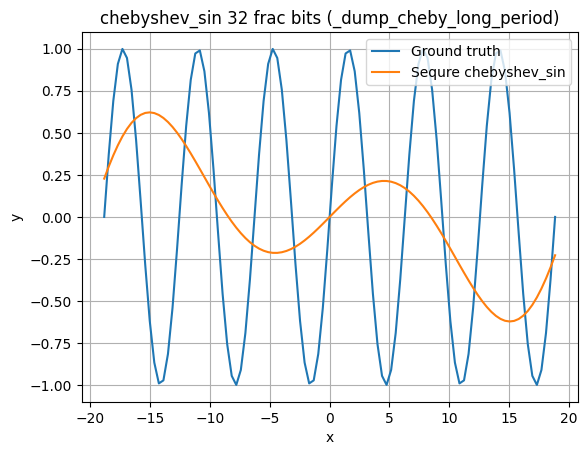

In [28]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot(title, label, x, result, expected):
    plt.plot(x, expected, label=f'Ground truth')
    plt.plot(x, result, label=f'Sequre {label}')
    plt.title(title)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)
    plt.show()

def mae(result, expected):
    return np.mean(np.abs(np.array(result) - np.array(expected)))


# Until Codon Jupyter is fixed: Read the data from file
dump_files = [
    "_dump_beaver_trig",
    "_dump_beaver_exp",
    "_dump_fourier_full_circle",
    "_dump_fourier_partial_circle",
    "_dump_fourier_positive_quad",
    "_dump_fourier_long_period",
    "_dump_cheby_full_circle",
    "_dump_cheby_partial_circle",
    "_dump_cheby_positive_quad",
    "_dump_cheby_long_period"
]

nbit_fs = [20, 32]

df_data = {
    'Method': [],
    'Interval': [],
    'MAE': [],
    'Runtime': []}

for dump_file in dump_files:
    for nbit_f in nbit_fs:
        with open(f"{dump_file}_{nbit_f}.p", "rb") as f:
            data = pickle.load(f)
            x = data['x']
            interval = f"({round(min(x), 2)}, {round(max(x), 2)})"
            for k, v in data.items():
                if k == 'x' or k.endswith("_expected") or k.endswith("_time"):
                    continue
                expected = data[f"{k}_expected"]
                runtime = round(data[f"{k}_time"][0], 5)
                
                df_data['Method'].append(f"{k}_{nbit_f}")
                df_data['Interval'].append(interval)
                df_data['MAE'].append(mae(v, expected))
                df_data['Runtime'].append(runtime)
                
                plot(f"{k} {nbit_f} frac bits ({dump_file})", k, x, v, expected)

df = pd.DataFrame(df_data)

In [29]:
df[df['Method'].str.contains('sin')].sort_values(by='MAE')

,Method,Interval,MAE,Runtime
72,chebyshev_sin_32,"(0.79, 2.36)",3.727602e-10,0.00173
3,beaver_sin_32,"(-3.14, 3.14)",5.152460e-10,0.00028
11,fourier_sin_32,"(-3.14, 3.14)",5.245350e-10,0.14059
41,fourier_sin_32,"(-18.85, 18.85)",2.755760e-09,0.01411
59,chebyshev_sin_32,"(-1.0, 2.5)",7.257183e-07,0.00136
65,chebyshev_sin_20,"(0.79, 2.36)",1.545054e-06,0.00123
55,chebyshev_sin_20,"(-1.0, 2.5)",1.940447e-06,0.00099
7,fourier_sin_20,"(-3.14, 3.14)",2.166385e-06,0.14916
1,beaver_sin_20,"(-3.14, 3.14)",2.256899e-06,0.00037
37,fourier_sin_20,"(-12.57, 12.57)",8.014935e-06,0.01311


In [30]:
df[df['Method'].str.contains('cos')].sort_values(by='MAE')

,Method,Interval,MAE,Runtime
2,beaver_cos_32,"(-3.14, 3.14)",5.271152e-10,0.00032
13,fourier_cos_32,"(-3.14, 3.14)",5.520564e-10,0.01358
68,chebyshev_cos_32,"(0.79, 2.36)",8.565026e-10,0.00107
43,fourier_cos_32,"(-18.85, 18.85)",2.799076e-09,0.01321
56,chebyshev_cos_32,"(-1.0, 2.5)",6.760736e-07,0.00140
61,chebyshev_cos_20,"(0.79, 2.36)",1.240716e-06,0.00059
52,chebyshev_cos_20,"(-1.0, 2.5)",1.839974e-06,0.00059
0,beaver_cos_20,"(-3.14, 3.14)",2.194746e-06,0.00023
9,fourier_cos_20,"(-3.14, 3.14)",2.205285e-06,0.01330
39,fourier_cos_20,"(-12.57, 12.57)",7.867061e-06,0.01286


In [31]:
df[df['Method'].str.contains('exp')].sort_values(by='MAE')

,Method,Interval,MAE,Runtime
70,chebyshev_exp_32,"(0.79, 2.36)",4.124148e-09,0.00107
5,beaver_expc_32,"(0.0, 6.28)",7.687383e-08,0.04645
57,chebyshev_exp_32,"(-1.0, 2.5)",2.426234e-06,0.00069
53,chebyshev_exp_20,"(-1.0, 2.5)",3.755082e-06,0.00126
63,chebyshev_exp_20,"(0.79, 2.36)",6.241961e-06,0.00094
49,chebyshev_exp_32,"(-3.14, 3.14)",2.600740e-04,0.00205
45,chebyshev_exp_20,"(-3.14, 3.14)",2.601227e-04,0.00059
4,beaver_expc_20,"(0.0, 6.28)",2.872094e-04,0.02872
30,fourier_exp_32,"(0.79, 2.36)",3.009865e-01,0.01695
23,fourier_exp_20,"(0.79, 2.36)",3.009865e-01,0.01667


In [32]:
df[df['Method'].str.contains('sigmoid')].sort_values(by='MAE')

,Method,Interval,MAE,Runtime
71,chebyshev_sigmoid_32,"(0.79, 2.36)",4.554214e-10,0.00176
58,chebyshev_sigmoid_32,"(-1.0, 2.5)",1.557623e-06,0.00112
64,chebyshev_sigmoid_20,"(0.79, 2.36)",1.635992e-06,0.00068
54,chebyshev_sigmoid_20,"(-1.0, 2.5)",2.421249e-06,0.00062
50,chebyshev_sigmoid_32,"(-3.14, 3.14)",2.293996e-04,0.00067
46,chebyshev_sigmoid_20,"(-3.14, 3.14)",2.293998e-04,0.00114
27,fourier_sigmoid_20,"(0.79, 2.36)",8.161183e-03,0.01290
34,fourier_sigmoid_32,"(0.79, 2.36)",8.161617e-03,0.01304
16,fourier_sigmoid_20,"(-1.0, 2.5)",2.360768e-02,0.01425
20,fourier_sigmoid_32,"(-1.0, 2.5)",2.360811e-02,0.01344


In [33]:
df[df['Method'].str.contains('sqrt')].sort_values(by='MAE')

,Method,Interval,MAE,Runtime
73,chebyshev_sqrt_32,"(0.79, 2.36)",1.134403e-07,0.00105
66,chebyshev_sqrt_20,"(0.79, 2.36)",1.536715e-06,0.00063
22,fourier_sqrt_20,"(0.79, 2.36)",2.336410e-02,0.01288
29,fourier_sqrt_32,"(0.79, 2.36)",2.336460e-02,0.01330


In [34]:
df[df['Method'].str.contains('mul_inv')].sort_values(by='MAE')

,Method,Interval,MAE,Runtime
60,chebyshev_mul_inv_20,"(0.79, 2.36)",0.000006,0.00122
67,chebyshev_mul_inv_32,"(0.79, 2.36)",0.000006,0.00172
25,fourier_mul_inv_20,"(0.79, 2.36)",0.030547,0.01274
32,fourier_mul_inv_32,"(0.79, 2.36)",0.030547,0.01311


In [35]:
df[df['Method'].str.contains('log')].sort_values(by='MAE')

,Method,Interval,MAE,Runtime
69,chebyshev_log_32,"(0.79, 2.36)",9.810289e-07,0.00140
62,chebyshev_log_20,"(0.79, 2.36)",1.737577e-06,0.00088
26,fourier_log_20,"(0.79, 2.36)",3.955901e-02,0.01287
33,fourier_log_32,"(0.79, 2.36)",3.955955e-02,0.01359
